In [1]:
import pandas as pd
import numpy as np

from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
df = pd.read_csv("../../datasets/Liver_Patient_Dataset.csv", encoding='latin1')
df.head()

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [5]:
df.columns

Index(['Age of the patient', 'Gender of the patient', 'Total Bilirubin',
       'Direct Bilirubin', ' Alkphos Alkaline Phosphotase',
       ' Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase',
       'Total Protiens', ' ALB Albumin',
       'A/G Ratio Albumin and Globulin Ratio', 'Result'],
      dtype='str')

In [ ]:
df.columns = df.columns.str.strip()  # remove extra spaces
df.columns = df.columns.str.replace(' ', '_')  

print(df.columns)

Index(['Age_of_the_patient', 'Gender_of_the_patient', 'Total_Bilirubin',
       'Direct_Bilirubin', 'Alkphos_Alkaline_Phosphotase',
       'Sgpt_Alamine_Aminotransferase', 'Sgot_Aspartate_Aminotransferase',
       'Total_Protiens', 'ALB_Albumin', 'A/G_Ratio_Albumin_and_Globulin_Ratio',
       'Result'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age_of_the_patient                    30689 non-null  float64
 1   Gender_of_the_patient                 29789 non-null  str    
 2   Total_Bilirubin                       30043 non-null  float64
 3   Direct_Bilirubin                      30130 non-null  float64
 4   Alkphos_Alkaline_Phosphotase          29895 non-null  float64
 5   Sgpt_Alamine_Aminotransferase         30153 non-null  float64
 6   Sgot_Aspartate_Aminotransferase       30229 non-null  float64
 7   Total_Protiens                        30228 non-null  float64
 8   ALB_Albumin                           30197 non-null  float64
 9   A/G_Ratio_Albumin_and_Globulin_Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), int64(1), s

In [8]:
df.describe()

,Age_of_the_patient,Total_Bilirubin,Direct_Bilirubin,Alkphos_Alkaline_Phosphotase,Sgpt_Alamine_Aminotransferase,Sgot_Aspartate_Aminotransferase,Total_Protiens,ALB_Albumin,A/G_Ratio_Albumin_and_Globulin_Ratio,Result
count,30689.000000,30043.000000,30130.000000,29895.000000,30153.000000,30229.000000,30228.000000,30197.000000,30132.000000,30691.000000
mean,44.107205,3.370319,1.528042,289.075364,81.488641,111.469979,6.480237,3.130142,0.943467,1.285882
std,15.981043,6.255522,2.869592,238.537589,182.158850,280.851078,1.081980,0.792281,0.323164,0.451841
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,32.000000,0.800000,0.200000,175.000000,23.000000,26.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,209.000000,35.000000,42.000000,6.600000,3.100000,0.900000,1.000000
75%,55.000000,2.700000,1.300000,298.000000,62.000000,88.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [10]:
df.isnull().sum()

Age_of_the_patient                        2
Gender_of_the_patient                   902
Total_Bilirubin                         648
Direct_Bilirubin                        561
Alkphos_Alkaline_Phosphotase            796
Sgpt_Alamine_Aminotransferase           538
Sgot_Aspartate_Aminotransferase         462
Total_Protiens                          463
ALB_Albumin                             494
A/G_Ratio_Albumin_and_Globulin_Ratio    559
Result                                    0
dtype: int64

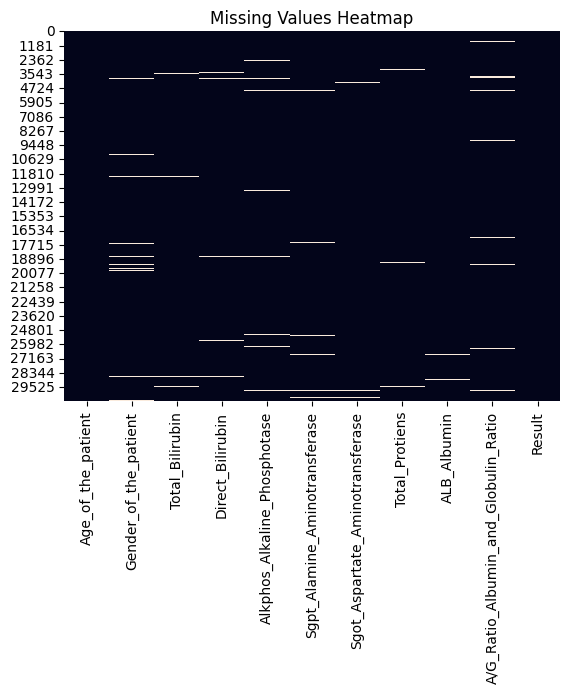

In [11]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

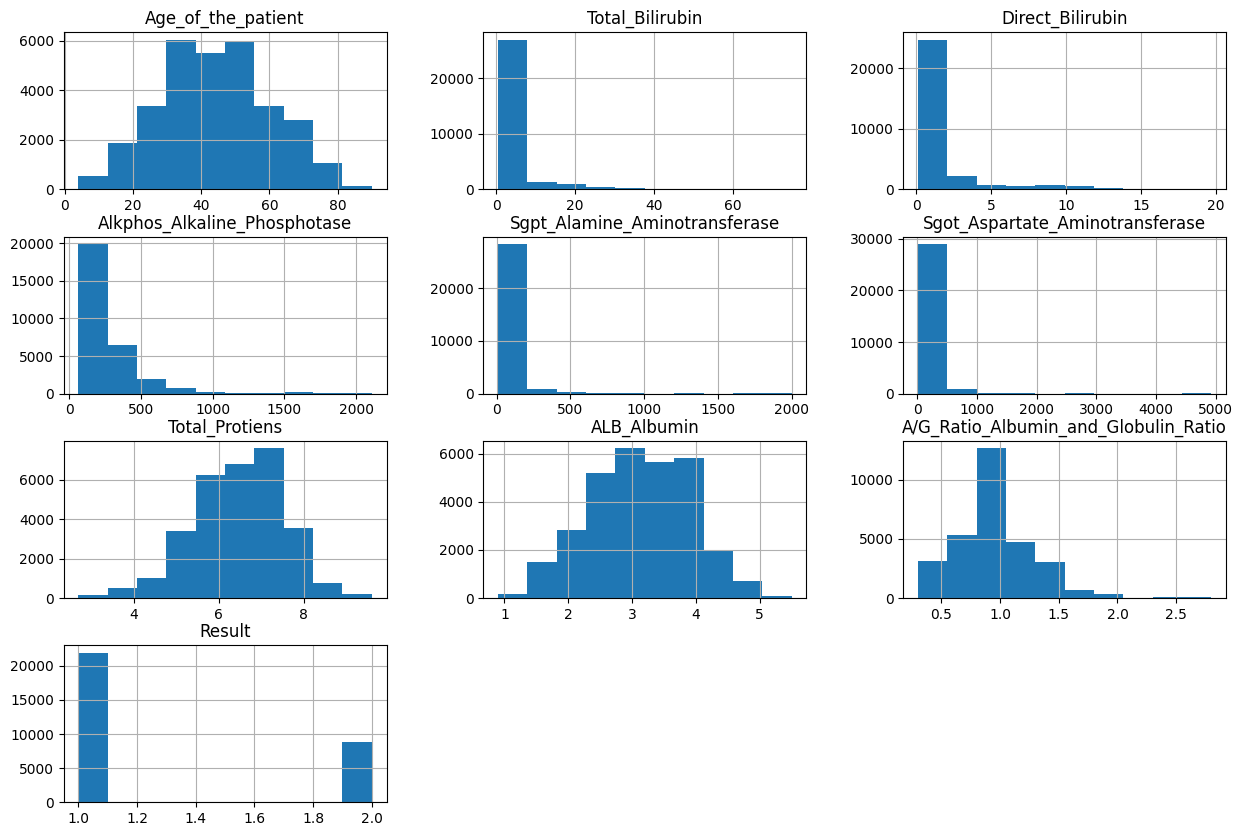

In [12]:
df.hist(figsize=(15,10))
plt.show()

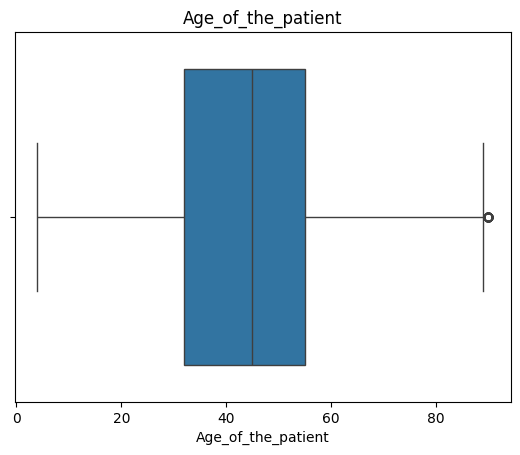

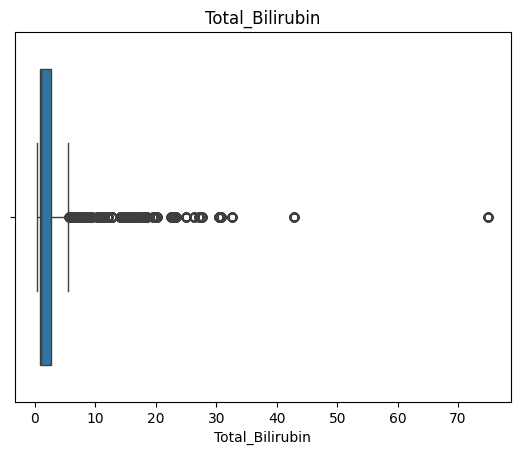

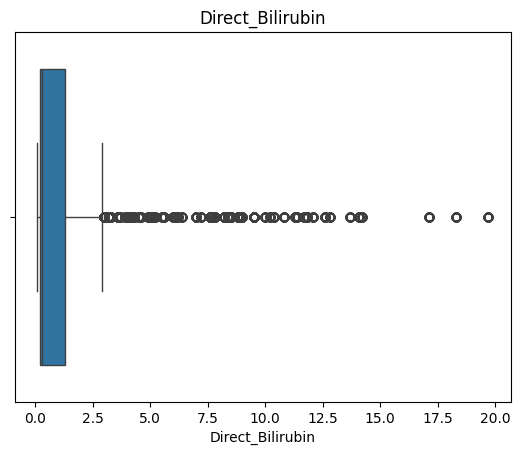

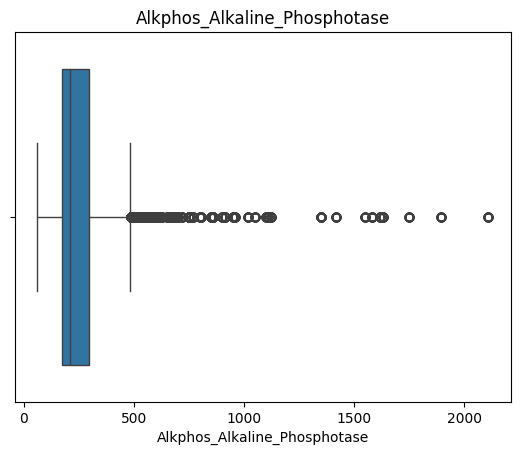

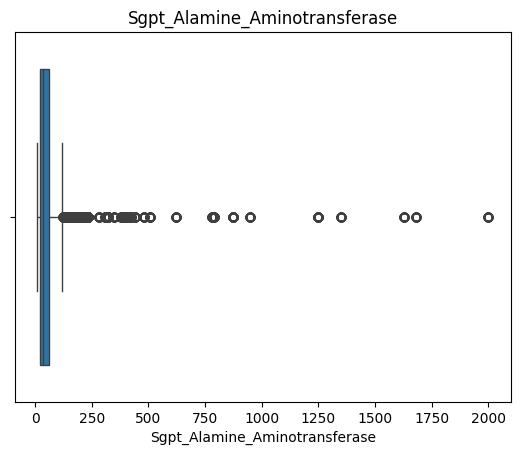

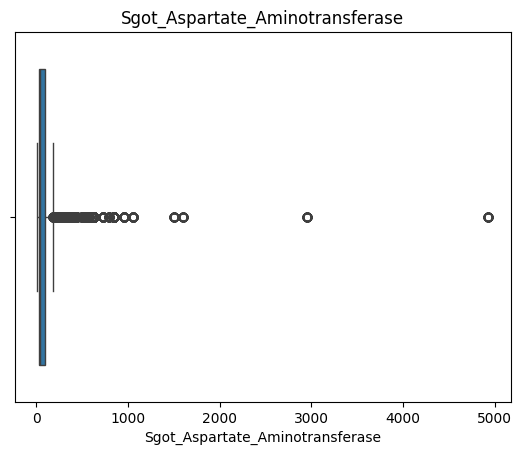

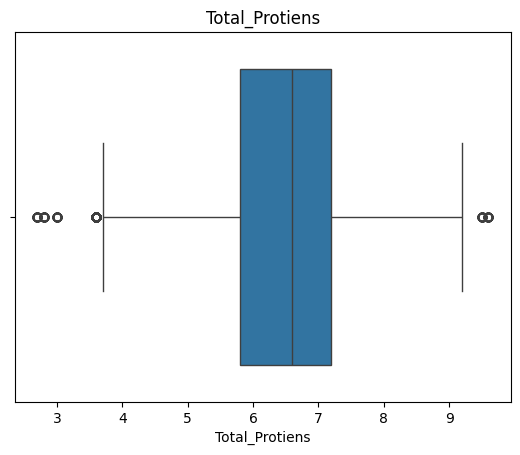

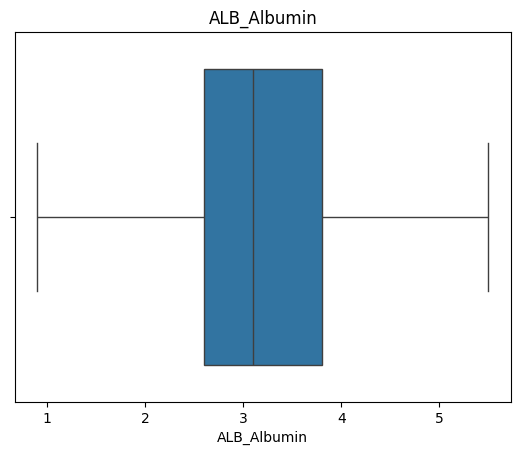

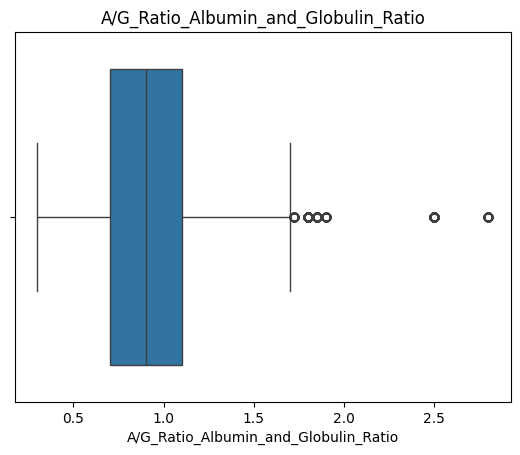

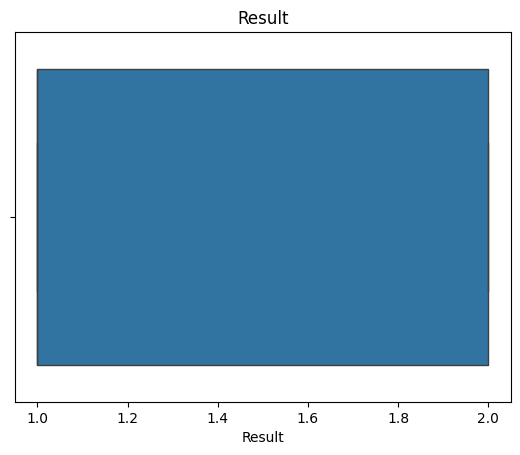

In [13]:
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

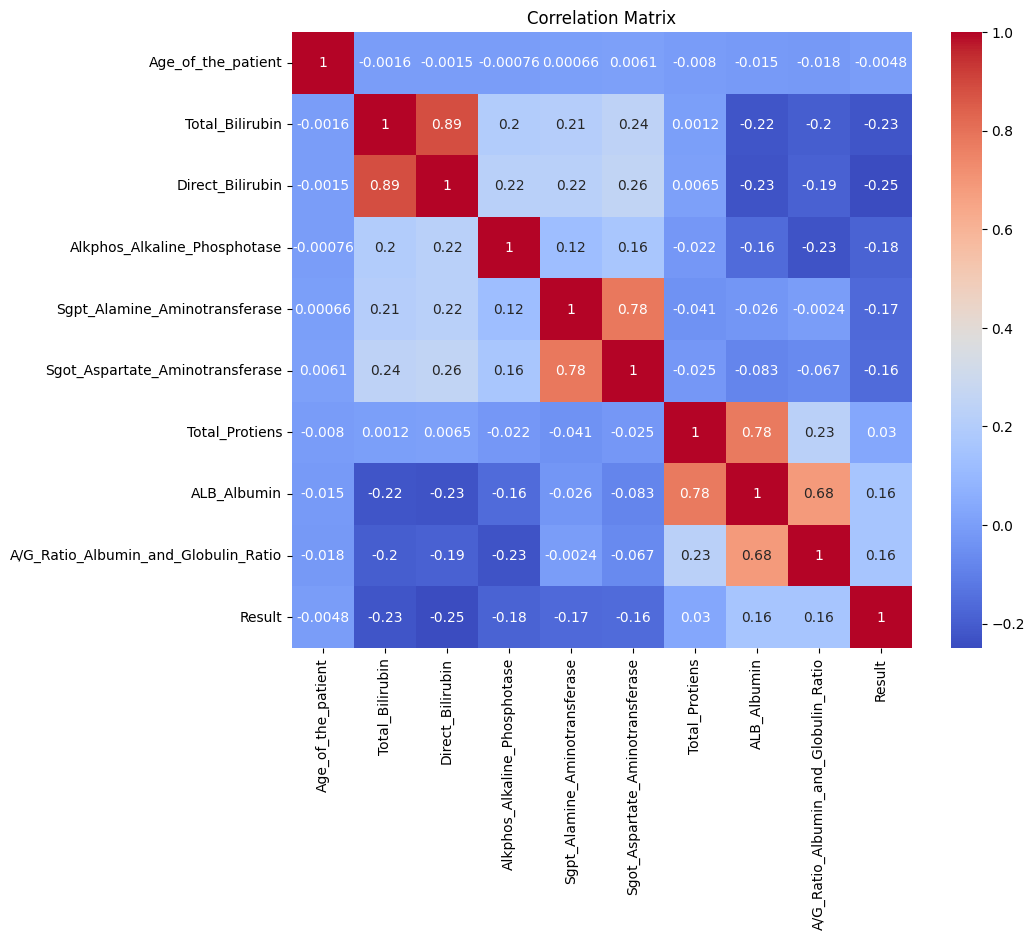

In [20]:
corr = df.select_dtypes(include='number').corr()



plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

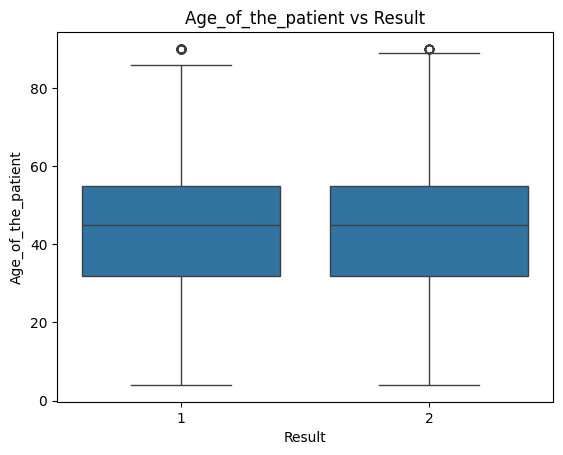

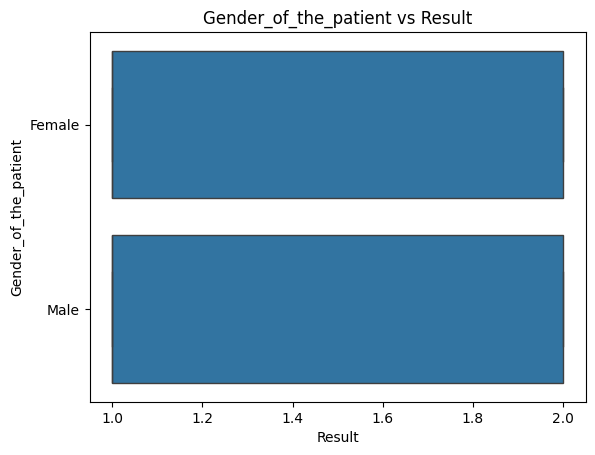

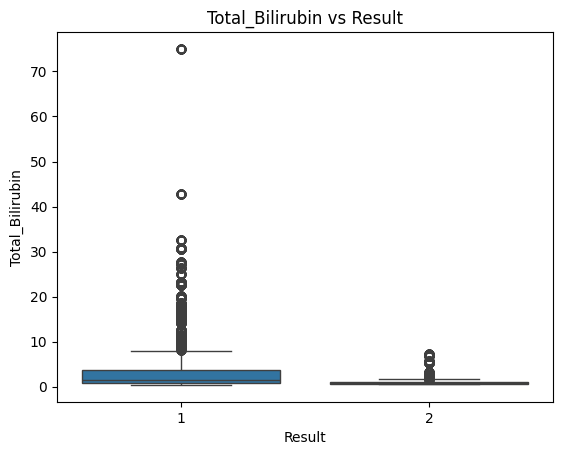

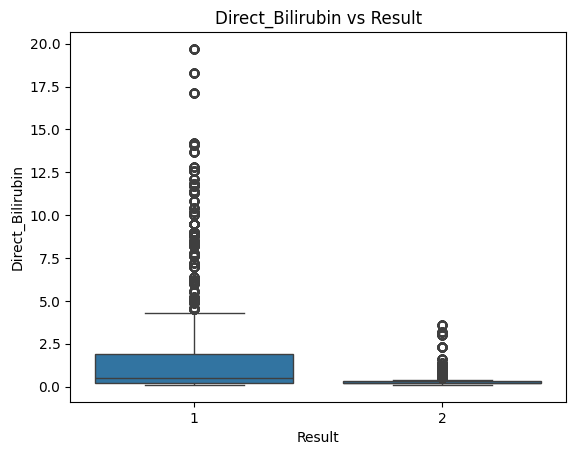

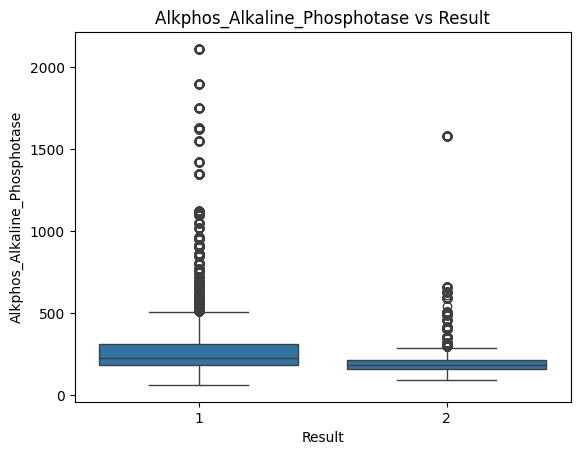

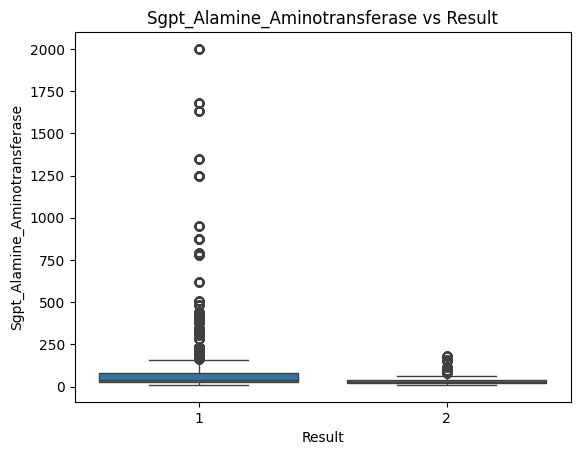

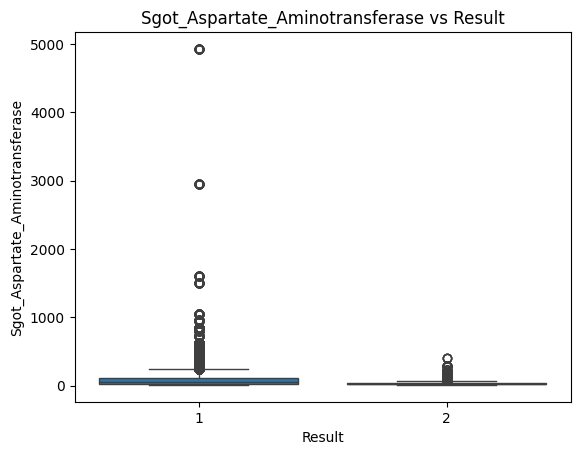

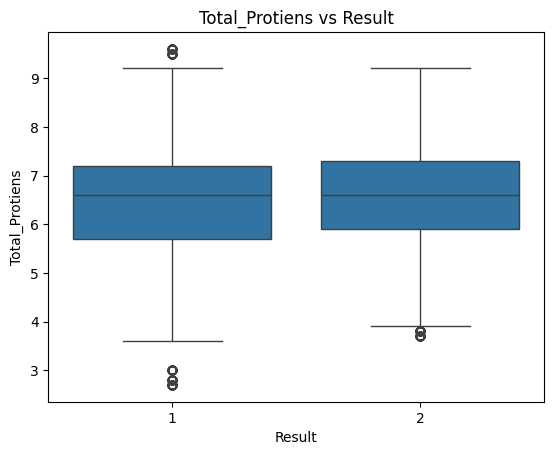

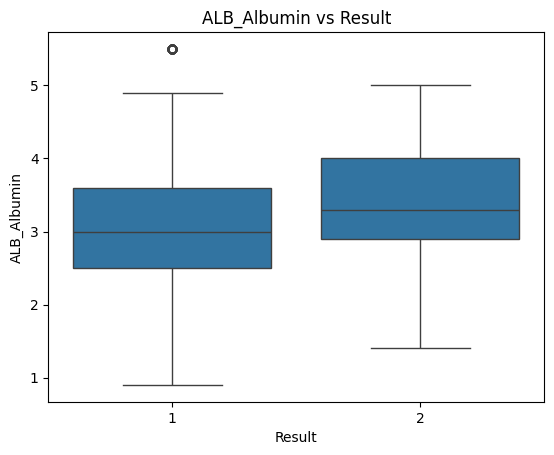

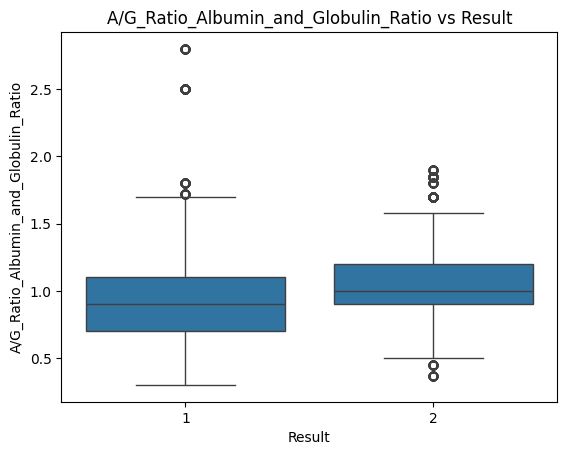

In [21]:
for col in df.columns[:-1]:
    sns.boxplot(x='Result', y=col, data=df)
    plt.title(f"{col} vs Result")
    plt.show()

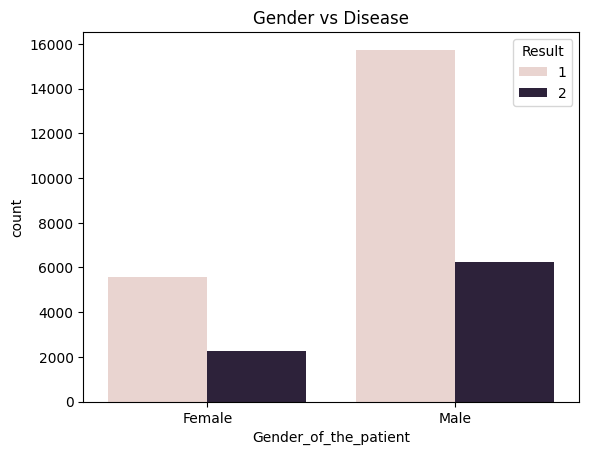

In [22]:
sns.countplot(x='Gender_of_the_patient', hue='Result', data=df)
plt.title("Gender vs Disease")
plt.show()

In [24]:
df['Gender_of_the_patient'] = df['Gender_of_the_patient'].map({
    'Male': 1,
    'Female': 0
})

df.skew()

Age_of_the_patient                       0.027818
Gender_of_the_patient                   -1.082894
Total_Bilirubin                          4.664615
Direct_Bilirubin                         3.156765
Alkphos_Alkaline_Phosphotase             3.777566
Sgpt_Alamine_Aminotransferase            6.456477
Sgot_Aspartate_Aminotransferase         10.344620
Total_Protiens                          -0.290544
ALB_Albumin                             -0.038985
A/G_Ratio_Albumin_and_Globulin_Ratio     1.057626
Result                                   0.947821
dtype: float64